# Flight Delay Prediction: Exploratory Data Analysis

**Phase 1 (Machine Learning) | Criterion: Dataset Quality & EDA**
**Data:** all flights leaving New York (JFK, LGA, EWR) in 2013, from `raw_data/flights.csv`.

## What this notebook does, in one paragraph

Before building any model we ask simple questions of the data and write down the answers. Every section below ends with a **Decision**: something the project will actually do because of what we found. If a chart did not change a decision, it is not in this notebook.

## The three rules of the project

| Rule | Meaning in plain words |
|---|---|
| **Predict before departure** | We pretend it is 6 PM the day before. We know the *schedule*, not what actually happened. |
| **No peeking at the future** | Any average (like "this airline's delay rate") may only use *earlier* days. |
| **Split by date** | Train on early months, test on later months. Never shuffle. |

## Contents
1. Load the data
2. Missing values and the target
3. Delays by hour, weekday and month
4. Airline, airport, destination and distance
5. Leakage: which columns are forbidden
6. The date split (the most important finding)
7. Which features carry signal?
8. Do features interact? (the case for deep learning)
9. Findings and decisions

## 1. Load the data

All project choices live in one place (`CONFIG`), so nothing is hidden inside the code. We also make a `figures/` folder, because every chart is saved there for the report.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

# Find the project folder (works whether you run from the project folder or from notebooks/)
ROOT = "." if os.path.exists("./raw_data/flights.csv") else ".."
FIG = f"{ROOT}/figures"
os.makedirs(FIG, exist_ok=True)

CONFIG = {
    "data_path": "raw_data/flights.csv",
    "delay_minutes": 15,                    # "delayed" = arrived 15+ minutes late (US FAA standard)
    "train_months": [1, 2, 3, 4, 5, 6, 7, 8],
    "val_months":   [9, 10],
    "test_months":  [11, 12],
}

In [2]:
raw = pd.read_csv(f"{ROOT}/{CONFIG['data_path']}")
print("Rows and columns:", raw.shape)
raw.head()

Rows and columns: (336776, 21)


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


One row is **one scheduled flight on one day**. The columns fall into three groups:

| Group | Columns | Known at 6 PM the day before? |
|---|---|---|
| **Schedule** | `year, month, day, hour, minute, sched_dep_time, sched_arr_time, carrier, flight, origin, dest, distance` | Yes |
| **What actually happened** | `dep_time, dep_delay, arr_time, air_time` | **No. Forbidden** |
| **Target** | `arr_delay` | This is what we predict |

`id` is only a row counter and `name` repeats `carrier`. Both are useless. `tailnum` (the aircraft) is left out for now, because using it safely needs "was the plane's previous flight already finished?", which is a later-stage question.

## 2. Missing values and the target

**Why missing values matter here:** they are not random errors. A cancelled flight never departed, so `dep_time` is empty. A diverted flight never arrived where planned, so `arr_delay` is empty.

**The target:** `delayed = 1` if the flight arrived **15 or more minutes late**, else `0`.

In [3]:
print(raw[["dep_time", "arr_time", "arr_delay", "tailnum"]].isna().sum())

df = raw.dropna(subset=["arr_delay"]).copy()          # drop flights with no arrival delay
df["y"] = (df["arr_delay"] >= CONFIG["delay_minutes"]).astype(int)

print(f"\nKept {len(df):,} of {len(raw):,} flights ({len(df)/len(raw):.1%})")
print(f"Base rate (share of flights delayed): {df['y'].mean():.2%}")

dep_time     8255
arr_time     8713
arr_delay    9430
tailnum      2512
dtype: int64

Kept 327,346 of 336,776 flights (97.2%)
Base rate (share of flights delayed): 24.47%


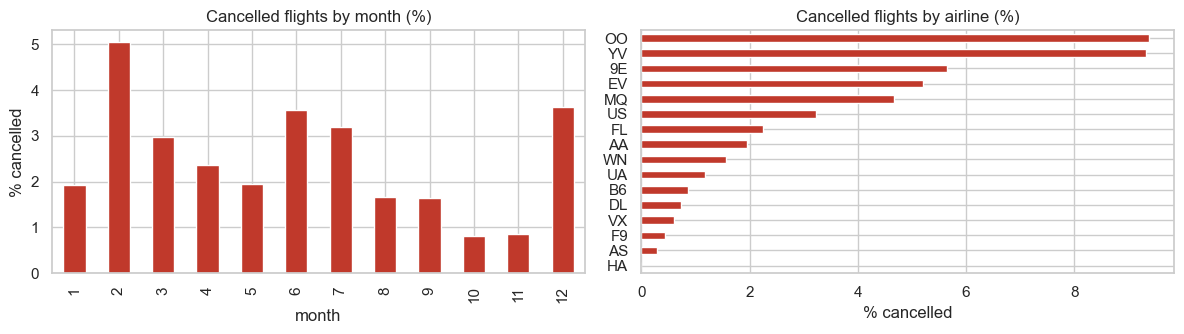

In [4]:
# Where do the missing flights come from?
raw["cancelled"] = raw["dep_time"].isna()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
raw.groupby("month")["cancelled"].mean().mul(100).plot.bar(ax=ax[0], color="#c0392b")
ax[0].set(title="Cancelled flights by month (%)", xlabel="month", ylabel="% cancelled")
raw.groupby("carrier")["cancelled"].mean().mul(100).sort_values().plot.barh(ax=ax[1], color="#c0392b")
ax[1].set(title="Cancelled flights by airline (%)", xlabel="% cancelled", ylabel="")
plt.tight_layout(); plt.savefig(f"{FIG}/01_cancellations.png", dpi=130); plt.show()

**What we see:** about 2.8% of flights have no arrival delay (8,255 cancelled, 1,175 diverted or missing). Cancellations cluster in a few months, which is a sign of storms.

**Decision 1.** Drop these flights from the main experiment, because the target is undefined for them. **State it as a limitation:** removing them makes stormy days look slightly better than they were.

**Decision 2.** About **1 flight in 4 is delayed** (base rate 24.5%). So *accuracy is a bad metric*: a model that always says "not delayed" scores 75.5%. We report **PR AUC**, **ROC AUC** and **recall at a fixed precision**, as the project brief asks.

## 3. Delays by hour, weekday and month

Time is where the strongest *legal* signals live, because the calendar and the schedule are known in advance.

We use one small helper for all "delay rate per group" charts. The black line on each bar is a rough **95% margin of error**: a long line means the group is small and its rate is unreliable.

In [5]:
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df["weekday"] = df["date"].dt.dayofweek            # 0 = Monday
overall = df["y"].mean() * 100

def rate_bar(ax, col, title):
    g = df.groupby(col)["y"].agg(["mean", "size"])
    err = 1.96 * np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"]) * 100     # margin of error
    ax.bar(g.index.astype(str), g["mean"] * 100, yerr=err, capsize=2, color="#2c7fb8")
    ax.axhline(overall, color="red", ls="--", lw=1)
    ax.set(title=title, xlabel=col, ylabel="% delayed")

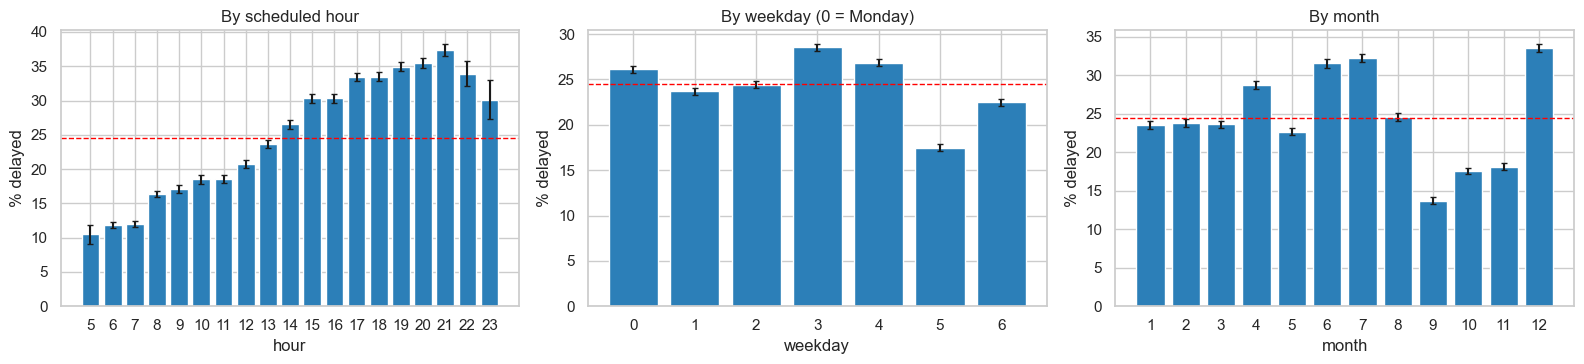

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
rate_bar(ax[0], "hour", "By scheduled hour")
rate_bar(ax[1], "weekday", "By weekday (0 = Monday)")
rate_bar(ax[2], "month", "By month")
plt.tight_layout(); plt.savefig(f"{FIG}/02_time_patterns.png", dpi=130); plt.show()

**What we see (red dashed line = overall rate):**
- **Hour:** delays climb from about 10% for early flights to about 37% for evening flights. The reason is the **knock-on effect**: a plane delayed in the morning makes its own afternoon flight late. This is the strongest pattern in the data.
- **Weekday:** Saturday is much calmer (about 17%) and Thursday is the worst (about 28%). Real business-travel rhythm.
- **Month:** summer and December are bad, September is the calmest (about 14%).

**Decision 3.** Scheduled hour, weekday and month are core features. Hour and weekday are cyclic (23:00 is next to 00:00, Sunday is next to Monday), so we encode them as `sin` and `cos`.

**Decision 4 (important).** A model cannot *memorise* month here. Section 6 shows why: the validation months never appear in training. Month can only enter as a **smooth seasonal curve** (`sin` and `cos` of the day of the year).

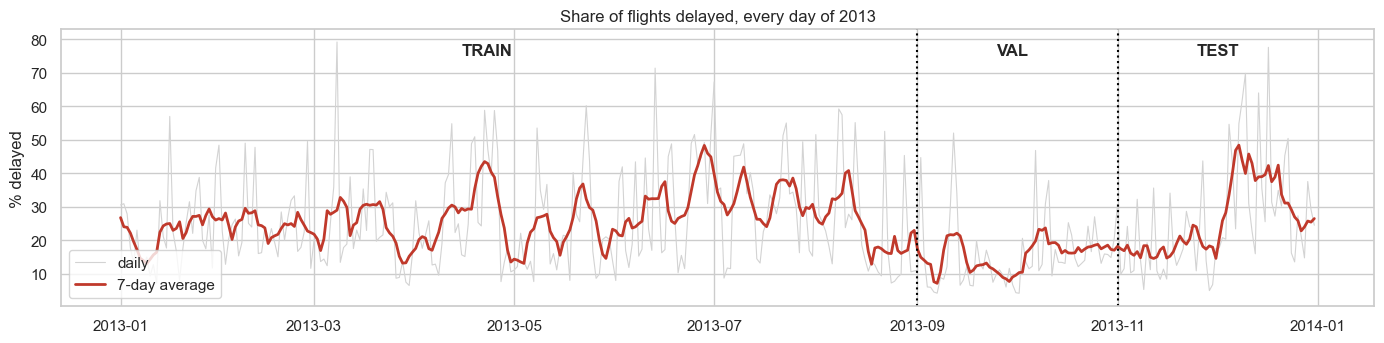

Five worst days:
 date
2013-03-08    79.2
2013-12-17    77.6
2013-06-13    71.4
2013-12-10    69.8
2013-07-01    67.3
Name: y, dtype: float64


In [7]:
# The whole year in one picture: storms, calm periods, and where our split falls
daily = df.groupby("date")["y"].mean() * 100
fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(daily.index, daily, color="lightgray", lw=0.8, label="daily")
ax.plot(daily.index, daily.rolling(7, center=True, min_periods=3).mean(), color="#c0392b", lw=2, label="7-day average")
for m in [9, 11]:
    ax.axvline(pd.Timestamp(f"2013-{m:02d}-01"), color="black", ls=":")
ax.set(title="Share of flights delayed, every day of 2013", ylabel="% delayed")
for x, label in [("2013-04-15", "TRAIN"), ("2013-09-25", "VAL"), ("2013-11-25", "TEST")]:
    ax.text(pd.Timestamp(x), 0.95, label, transform=ax.get_xaxis_transform(), fontweight="bold", va="top")
ax.legend(loc="lower left"); plt.tight_layout(); plt.savefig(f"{FIG}/03_daily_timeline.png", dpi=130); plt.show()
print("Five worst days:\n", daily.sort_values(ascending=False).head(5).round(1))

**What we see:** two things.

1. **Sharp spikes are real storms.** The worst day, 8 March 2013, had about 79% of flights delayed (a major winter storm). This dataset has **no weather columns**, so a day-before model **cannot see storms coming**. That sets a **ceiling** on how good any model can be. This must be written in the limitations.
2. **The validation window (Sep to Oct) is unusually calm**, and December (in the test set) has a storm cluster. The split is not evenly matched. Section 6 measures this.

## 4. Airline, airport, destination and distance

These are the categories the deep-learning model will turn into **embeddings**. Two questions: do groups differ, and are any groups too small to trust?

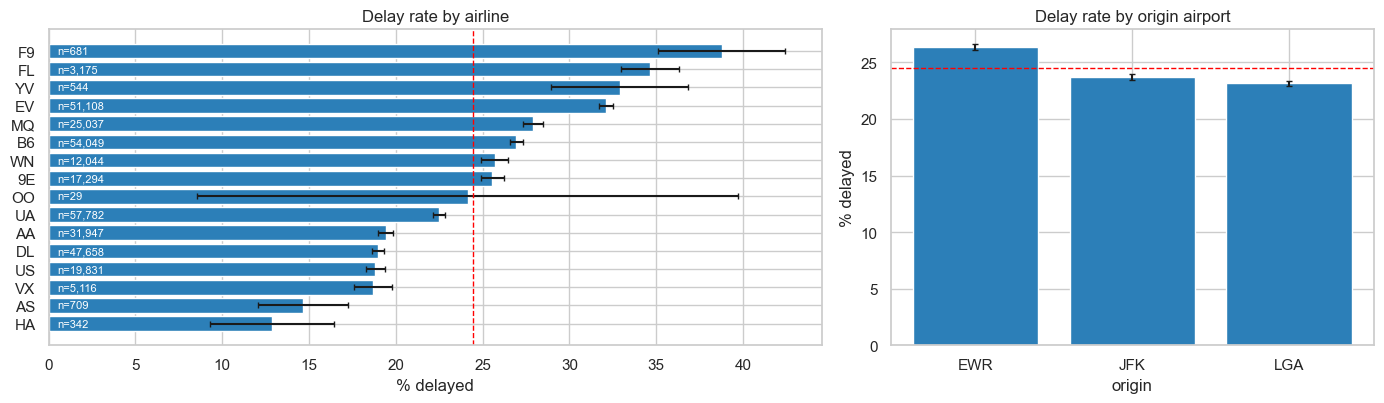

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
order = df.groupby("carrier")["y"].mean().sort_values().index
g = df.groupby("carrier")["y"].agg(["mean", "size"]).loc[order]
err = 1.96 * np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"]) * 100
ax[0].barh(g.index, g["mean"] * 100, xerr=err, capsize=2, color="#2c7fb8")
ax[0].axvline(overall, color="red", ls="--", lw=1)
for i, n in enumerate(g["size"]): ax[0].text(0.5, i, f"n={n:,}", va="center", fontsize=8, color="white")
ax[0].set(title="Delay rate by airline", xlabel="% delayed")
rate_bar(ax[1], "origin", "Delay rate by origin airport")
plt.tight_layout(); plt.savefig(f"{FIG}/04_carrier_origin.png", dpi=130); plt.show()

In [9]:
dest_n = df["dest"].value_counts()
print("Destinations:", len(dest_n))
print("  with fewer than 100 flights: ", (dest_n < 100).sum())
print("  with fewer than 1000 flights:", (dest_n < 1000).sum())
print(f"  top 10 destinations hold {dest_n.head(10).sum() / len(df):.0%} of all flights")
print("\ncorrelation between distance and delay:", round(df["distance"].corr(df["y"]), 3))

Destinations: 104
  with fewer than 100 flights:  12
  with fewer than 1000 flights: 48
  top 10 destinations hold 42% of all flights

correlation between distance and delay: -0.03


**What we see:**
- **Airlines differ a lot** (roughly 13% to 39%). But the tiny airlines (like `OO` with 29 flights) have long error lines: their rate is close to a guess.
- **The three origin airports barely differ.** Origin has only three values, so it carries little on its own.
- **Destinations are very uneven:** a few big airports dominate and 12 destinations have under 100 flights. Distance has almost no direct link to delay.

**Decision 5.** Never feed raw group averages to a model, because a small group's average is unreliable. We use **smoothing** (pull small groups toward the overall rate) and merge very rare destinations into an `"OTHER"` group.

**Decision 6.** Keep **distance** as the only length feature. Block time and distance are highly correlated (0.77), so they carry mostly the same information.

**Decision 7.** For the deep-learning embeddings, rare destinations get an almost random vector because they have too few examples. This is why XGBoost must be compared honestly: trees may handle rare categories better.

## 5. Leakage: which columns are forbidden

**Leakage** means the model sees something it could not know at prediction time. The scores look amazing and then collapse in real use. The biggest danger here is **`dep_delay`** (how late the plane actually left). We prove it with numbers.

In [10]:
late_dep = df["dep_delay"] >= 15
print(f"P(arrives delayed | left 15+ min late) = {df.loc[late_dep, 'y'].mean():.1%}")
print(f"P(arrives delayed | left on time)      = {df.loc[~late_dep, 'y'].mean():.1%}\n")

print("How well does each forbidden column predict the target ALONE? (0.5 = useless, 1.0 = perfect)")
for col in ["dep_delay", "dep_time", "arr_time", "air_time"]:
    s = df[[col, "y"]].dropna()
    auc = roc_auc_score(s["y"], s[col])
    print(f"  {col:10s} AUC = {max(auc, 1 - auc):.3f}")

P(arrives delayed | left 15+ min late) = 79.9%
P(arrives delayed | left on time)      = 8.7%

How well does each forbidden column predict the target ALONE? (0.5 = useless, 1.0 = perfect)
  dep_delay  AUC = 0.895
  dep_time   AUC = 0.666
  arr_time   AUC = 0.601
  air_time   AUC = 0.503


**What we see:** if a flight left 15+ minutes late, it arrives late **80%** of the time. If it left on time, only **9%**. A single forbidden column, `dep_delay`, reaches **AUC 0.89**. A model allowed to use it would look brilliant and be worthless.

**Decision 8. The rule for the whole project:**

| Category | Columns |
|---|---|
| **Forbidden** (known only after departure) | `dep_time`, `dep_delay`, `arr_time`, `air_time` |
| **Target** | `arr_delay` |
| **Useless** | `id`, `name` |
| **Allowed** | schedule columns, calendar columns, and statistics built from *earlier days only* |

Any model in this project that scores far above about 0.7 ROC AUC should be checked for leakage first.

## 6. The date split (the most important finding)

We split by date: **train** = Jan to Aug, **validation** = Sep to Oct, **test** = Nov to Dec. This copies real life (learn from the past, predict the future). But a date split has a side effect: **the seasons differ between the parts.**

In [11]:
split_of = {m: "train" for m in CONFIG["train_months"]}
split_of.update({m: "val" for m in CONFIG["val_months"]})
split_of.update({m: "test" for m in CONFIG["test_months"]})
df["split"] = df["month"].map(split_of)

tr, va, te = (df[df["split"] == s] for s in ["train", "val", "test"])
assert tr["date"].max() < va["date"].min() and va["date"].max() < te["date"].min(), "splits overlap in time!"

table = df.groupby("split")["y"].agg(flights="size", base_rate="mean").loc[["train", "val", "test"]]
table["base_rate_%"] = (table["base_rate"] * 100).round(1)
table[["flights", "base_rate_%"]]

,flights,base_rate_%
split,,
train,217727,26.4
val,55628,15.7
test,53991,25.8


**What we see:** the base rate is about **26% in train, 16% in validation, and 26% in test**. Validation is far calmer than the other two.

**Why this matters (read carefully, this is a common mistake):**

1. **PR AUC is measured against the base rate.** A useless model scores PR AUC ≈ base rate. So it scores about 0.16 on validation but about 0.26 on test. **The same PR AUC number means different things on the two sets.**
2. So we always report **lift = PR AUC divided by the base rate**. Lift 1.0 means "no better than guessing", lift 1.5 means "50% better than guessing", and this *can* be compared across splits.
3. **A threshold tuned on the calm validation months will misfire on the stormy test months.** We will say this openly in the report instead of hiding it.

**Decision 9.** Report **PR AUC, lift, ROC AUC, and recall at fixed precision** for every model, on validation and on test.

**Decision 10.** As a robustness check, also run a **rolling-origin test**: train Jan to Mar and test April, train Jan to Apr and test May, and so on. If a model wins on *every* fold, its win does not depend on one lucky cut.

**Decision 11.** Never fix the drift by shuffling or by choosing the split that flatters the results. That would be leakage in another form.

## 7. Which features carry signal?

We score each *legal* feature **alone**. For a category, we learn "delay rate per value" on **train only**, with smoothing so small groups are not trusted too much, then check on **validation**. An AUC of 0.50 means no signal.

We do **not** test `month` here: the validation months never appear in training, so a per-month lookup has nothing to look up (Decision 4).

We also add **congestion**: the number of flights scheduled from the same airport in the same hour. The schedule is public, so this is legal at 6 PM the day before.

In [12]:
df["cong_hour"] = df.groupby(["origin", "date", "hour"])["flight"].transform("size")
tr, va = df[df["split"] == "train"], df[df["split"] == "val"]

def smoothed_rates(train, col, k=50):
    # delay rate per value, pulled toward the overall rate when a value has few flights
    g = train.groupby(col)["y"].agg(["sum", "count"])
    prior = train["y"].mean()
    return (g["sum"] + k * prior) / (g["count"] + k), prior

rows = []
for col in ["hour", "weekday", "carrier", "dest", "origin"]:
    rate, prior = smoothed_rates(tr, col)
    score = va[col].map(rate).fillna(prior)
    rows.append((col, roc_auc_score(va["y"], score), average_precision_score(va["y"], score)))
for col in ["cong_hour", "distance"]:
    auc = roc_auc_score(va["y"], va[col])
    rows.append((col, max(auc, 1 - auc), average_precision_score(va["y"], va[col])))

signal = pd.DataFrame(rows, columns=["feature", "ROC_AUC", "PR_AUC"]).set_index("feature")
signal["lift"] = signal["PR_AUC"] / va["y"].mean()
signal.sort_values("ROC_AUC", ascending=False).round(3)

,ROC_AUC,PR_AUC,lift
feature,,,
hour,0.628,0.211,1.346
weekday,0.578,0.191,1.214
carrier,0.560,0.183,1.165
dest,0.546,0.181,1.151
cong_hour,0.522,0.144,0.915
distance,0.513,0.151,0.960
origin,0.499,0.158,1.008


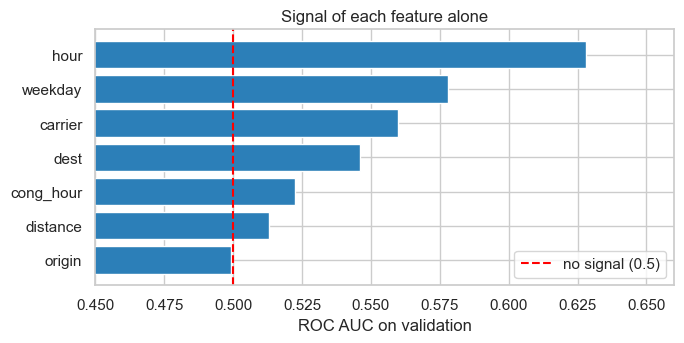

In [13]:
s = signal.sort_values("ROC_AUC")
plt.figure(figsize=(7, 3.6))
plt.barh(s.index, s["ROC_AUC"], color="#2c7fb8")
plt.axvline(0.5, color="red", ls="--", label="no signal (0.5)")
plt.xlim(0.45, 0.66); plt.xlabel("ROC AUC on validation"); plt.title("Signal of each feature alone")
plt.legend(); plt.tight_layout(); plt.savefig(f"{FIG}/05_feature_signal.png", dpi=130); plt.show()

**What we see:**
- **Hour is the strongest** (AUC about 0.63), then **weekday** (0.58), **airline** (0.56), **destination** (0.55).
- **Origin, distance and congestion are weak** on their own (0.50 to 0.52).
- **Every single feature is weak.** This is normal. It means the honest ceiling for a day-before model is modest, and gains must come from *combining* features.

**Decision 12.** Build the calendar and schedule features (hour, weekday, seasonal curve). Keep airline, destination and one congestion count as inputs. **Do not build holiday flags:** we tested them during this project (near-holiday days were actually *less* delayed, 18.5% vs 24.8%, and both flags scored AUC ≈ 0.50 to 0.51), so they add noise.

## 8. Do features interact? (the case for deep learning)

The project brief says hand-made summaries "may miss complex interactions". That is the whole reason to try deep learning, so we test it. If airline and hour acted **independently**, an *additive* model (airline effect + hour effect) would be enough. We compare it with a model that also has an **airline x hour** term.

In [14]:
def fit_and_score(with_interaction):
    def make_X(d):
        X = d[["carrier", "hour"]].astype(str)
        if with_interaction:
            X["carrier_x_hour"] = X["carrier"] + "_" + X["hour"]
        return X
    model = Pipeline([
        ("onehot", ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore", min_frequency=20),
                                       ["carrier", "hour"] + (["carrier_x_hour"] if with_interaction else []))])),
        ("logreg", LogisticRegression(max_iter=300, C=0.5)),
    ])
    model.fit(make_X(tr), tr["y"])
    p = model.predict_proba(make_X(va))[:, 1]
    return roc_auc_score(va["y"], p), average_precision_score(va["y"], p)

base_auc, base_pr = fit_and_score(False)
inter_auc, inter_pr = fit_and_score(True)
print(f"Additive    (airline + hour):        ROC AUC {base_auc:.4f} | PR AUC {base_pr:.4f} | lift {base_pr/va['y'].mean():.2f}")
print(f"Interaction (+ airline x hour):      ROC AUC {inter_auc:.4f} | PR AUC {inter_pr:.4f} | lift {inter_pr/va['y'].mean():.2f}")
print(f"Gain from interaction: {inter_auc - base_auc:+.4f} ROC AUC, {inter_pr - base_pr:+.4f} PR AUC")

Additive    (airline + hour):        ROC AUC 0.6477 | PR AUC 0.2368 | lift 1.51
Interaction (+ airline x hour):      ROC AUC 0.6505 | PR AUC 0.2402 | lift 1.53
Gain from interaction: +0.0028 ROC AUC, +0.0034 PR AUC


**What we see:** the interaction adds only about **+0.003 ROC AUC**. That is tiny.

**What it means:** for airline and hour, an additive model is already close to enough. This is an honest early sign that **gradient boosting on hand-built features may match the deep model**, and that any deep-learning gain will be small.

**Decision 13.** Keep the deep-learning hypothesis, but do not force it to win. If the MLP does not beat XGBoost, that is a **valid finding**, and the embedding analysis (do similar destinations cluster?) is where the deep model can still add value. This is a research result either way. Note this only tested one pair (airline x hour). It does not rule out other interactions such as airport x hour x recent delay.

## 9. Findings and decisions

The text in this notebook quotes numbers (like "about 37% at night"). Text can go out of date, so the cell below **checks each quoted number against the live data** and prints `OK` or `CHECK`. Run it after any change.

In [15]:
hour_rate = df.groupby("hour")["y"].mean() * 100
weekday_rate = df.groupby("weekday")["y"].mean() * 100
split_rate = df.groupby("split")["y"].mean() * 100
dep_auc = max(roc_auc_score(df["y"], df["dep_delay"]), 1 - roc_auc_score(df["y"], df["dep_delay"]))

checks = [
    ("base rate is about 24.5%",                     abs(df["y"].mean() * 100 - 24.5) < 1),
    ("2.8% of flights unlabelled",                   abs((1 - len(df) / len(raw)) * 100 - 2.8) < 0.3),
    ("late-evening hours reach 30% or more",         hour_rate.max() >= 30),
    ("early-morning hours are under 15%",            hour_rate.min() < 15),
    ("Saturday is the calmest weekday",              weekday_rate.idxmin() == 5),
    ("validation base rate is 16%, about 10 points below train", 8 < split_rate["train"] - split_rate["val"] < 12),
    ("dep_delay alone has AUC about 0.89",           abs(dep_auc - 0.89) < 0.03),
    ("hour is the strongest single feature",         signal["ROC_AUC"].idxmax() == "hour"),
]
for text, ok in checks:
    print("OK    " if ok else "CHECK ", text)
print("\nAll quoted numbers match." if all(ok for _, ok in checks) else "\nSome text no longer matches the data: update it.")

OK     base rate is about 24.5%
OK     2.8% of flights unlabelled
OK     late-evening hours reach 30% or more
OK     early-morning hours are under 15%
OK     Saturday is the calmest weekday
OK     validation base rate is 16%, about 10 points below train
OK     dep_delay alone has AUC about 0.89
OK     hour is the strongest single feature

All quoted numbers match.


### The summary

This table is the **summary to cite in the report**. Every row is backed by a figure or a number above.

| # | Finding | Decision |
|---|---|---|
| 1 | 2.8% of flights have no arrival delay (cancelled or diverted) | Drop them. State the selection bias. |
| 2 | 1 in 4 flights is delayed (24.5%) | Use PR AUC, lift, ROC AUC, recall at fixed precision. Never accuracy. |
| 3 | Delays rise through the day (about 10% to 37%) | `sin`/`cos` of hour. Core feature. |
| 4 | Weekday matters (Saturday calm, Thursday worst) | `sin`/`cos` of weekday. Core feature. |
| 5 | Strong seasonal pattern; validation months never seen in training | Seasonal curve (`sin`/`cos` of day of year), not a month category. |
| 6 | Airlines differ a lot; small ones are unreliable | Smooth rates. Merge rare categories. |
| 7 | 12 destinations have under 100 flights | Merge into `"OTHER"`. Compare MLP with XGBoost honestly. |
| 8 | `dep_delay` alone gives AUC 0.89 | **Forbidden**, plus `dep_time`, `arr_time`, `air_time`. |
| 9 | **Validation base rate 16% vs 26% in train and test** | Report **lift**. Add rolling-origin folds. |
| 10 | Storms cause spikes that a schedule cannot predict | **No weather = a ceiling.** State in limitations. |
| 11 | Every single feature is weak alone | Expect a modest ceiling. Gains come from combining. |
| 12 | Holiday flags scored about 0.50 AUC | Not built. |
| 13 | Airline x hour interaction adds only +0.003 AUC | Keep the DL hypothesis, do not force a win. |

### What the next notebook (`02_features`) builds

| Group | Features | Leakage status |
|---|---|---|
| Calendar | `sin`/`cos` of hour, weekday and day of year | Safe |
| Schedule | scheduled hour, distance | Safe |
| Congestion | scheduled flights from the same airport in the same hour | Safe (schedule only) |
| Historical rates | delay rate by airline, destination, (origin, hour), computed from **earlier days only**, smoothed | Safe **only if** built with a time cutoff |
| Categories for embeddings | airline, origin, destination (rare ones merged) | Safe |

### Limitations to write in the report
1. **No weather.** Storms explain the big spikes, so scores are capped.
2. **One year and three origin airports.** No multi-year seasonality, and "origin" has only three values.
3. **The date split changes the season** between train, validation and test, and validation is unusually calm.
4. **Cancelled and diverted flights are excluded**, so extreme days look milder than they were.
5. **The rescheduling analysis (later) is a model-based what-if, not a causal estimate.**